In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textstat
from tqdm import tqdm

# integrating tqdm with pandas (to see a progress bar)
tqdm.pandas()

# seeing at most 100 columns
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv("billboard_lyrics_features_final.csv")
df = df.drop(columns=["flesch_kincaid_readability","lsa_component_1","lsa_component_2","lsa_component_3"])
print(df.head())
print(df.info())

   original_index   track_id            song_name   artist genre  \
0           17623  Pop_00001      A Child Is Born  Rihanna   Pop   
1           17624  Pop_00002       A Girl Like Me  Rihanna   Pop   
2           17626  Pop_00003      American Oxygen  Rihanna   Pop   
3           17627  Pop_00004  California King Bed  Rihanna   Pop   
4           17628  Pop_00005       Cold Case Love  Rihanna   Pop   

                                              lyrics  chorus_ratio  \
0  As I was walkin' down the road to Bethlehem on...        0.7317   
1  Some girls play the game  \r\nThey all walk an...        0.6486   
2  [Chorus]  \r\nBreathe out, breathe in  \r\nAme...        0.8143   
3  Chest to chest  \r\nNose to nose  \r\nPalm to ...        0.4894   
4  On my roof (roof, roof, roof)  \r\nDark and I'...        0.5424   

   syllable_density  sentiment_score  
0            1.6751              0.0  
1            1.4463              0.0  
2            2.3005              0.0  
3            1

In [3]:
print("1. Step: Sentiment Analysis (Sentiment Analysis)")
# We are downloading and preparing the VADER emotion analysis tool of the NLTK library
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# We take the 'compound' score of the lyrics (between -1 and Dec 1)
df['sentiment_score'] = df['lyrics'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])

1. Step: Sentiment Analysis (Sentiment Analysis)


100%|█████████████████████████████████████████████████████████████████████████████| 6813/6813 [00:26<00:00, 252.91it/s]


In [4]:
df.head(20)

,original_index,track_id,song_name,artist,genre,lyrics,chorus_ratio,syllable_density,sentiment_score
0,17623,Pop_00001,A Child Is Born,Rihanna,Pop,As I was walkin' down the road to Bethlehem on...,0.7317,1.6751,0.9985
1,17624,Pop_00002,A Girl Like Me,Rihanna,Pop,Some girls play the game \r\nThey all walk an...,0.6486,1.4463,0.9976
2,17626,Pop_00003,American Oxygen,Rihanna,Pop,"[Chorus] \r\nBreathe out, breathe in \r\nAme...",0.8143,2.3005,0.9195
3,17627,Pop_00004,California King Bed,Rihanna,Pop,Chest to chest \r\nNose to nose \r\nPalm to ...,0.4894,1.6163,0.7930
4,17628,Pop_00005,Cold Case Love,Rihanna,Pop,"On my roof (roof, roof, roof) \r\nDark and I'...",0.5424,1.4672,0.9987
5,17629,Pop_00006,Crazy Little Thing Called Love,Rihanna,Pop,Ooh yeah \r\nYeah yea \r\n \r\nWhen you sta...,0.1509,1.5616,0.9915
6,17630,Pop_00007,Cry,Rihanna,Pop,I'm not the type to get my heart broken \r\nI...,0.4906,1.4969,-0.9909
7,17631,Pop_00008,Dem Haters,Rihanna,Pop,[Verse 1] \r\nI'm not concerned with people ...,0.0968,1.4353,-0.9419
8,17632,Pop_00009,Disturbia,Rihanna,Pop,Bum bum be-dum bum bum be-dum bum \r\nBum bum...,0.5588,1.5927,-0.7672
9,17633,Pop_00010,Do Ya Thing,Rihanna,Pop,Know I'm missing that kissing in the Rover \r...,0.5119,1.2212,0.9996


<Axes: >

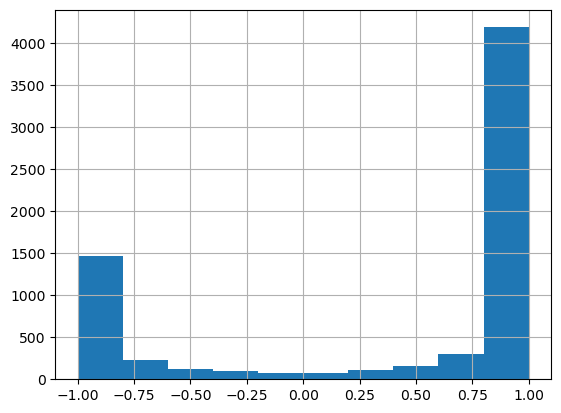

In [5]:
df['sentiment_score'].hist()

In [6]:
print("\n2. Step: Cognitive Analysis (Flesch-Kincaid Readability)")
# we calculate the Flesch-Kincaid convenience score using the textstat library
# Note: This metric measures linguistic complexity based on word and sentence lengths.
df['readability_score'] = df['lyrics'].progress_apply(lambda x: textstat.flesch_reading_ease(str(x)))


2. Step: Cognitive Analysis (Flesch-Kincaid Readability)


100%|█████████████████████████████████████████████████████████████████████████████| 6813/6813 [00:07<00:00, 896.98it/s]


In [7]:
df.head()

,original_index,track_id,song_name,artist,genre,lyrics,chorus_ratio,syllable_density,sentiment_score,readability_score
0,17623,Pop_00001,A Child Is Born,Rihanna,Pop,As I was walkin' down the road to Bethlehem on...,0.7317,1.6751,0.9985,-213.015852
1,17624,Pop_00002,A Girl Like Me,Rihanna,Pop,Some girls play the game \r\nThey all walk an...,0.6486,1.4463,0.9976,-288.069160
2,17626,Pop_00003,American Oxygen,Rihanna,Pop,"[Chorus] \r\nBreathe out, breathe in \r\nAme...",0.8143,2.3005,0.9195,-215.421805
3,17627,Pop_00004,California King Bed,Rihanna,Pop,Chest to chest \r\nNose to nose \r\nPalm to ...,0.4894,1.6163,0.7930,-159.395000
4,17628,Pop_00005,Cold Case Love,Rihanna,Pop,"On my roof (roof, roof, roof) \r\nDark and I'...",0.5424,1.4672,0.9987,-253.186955


<Axes: >

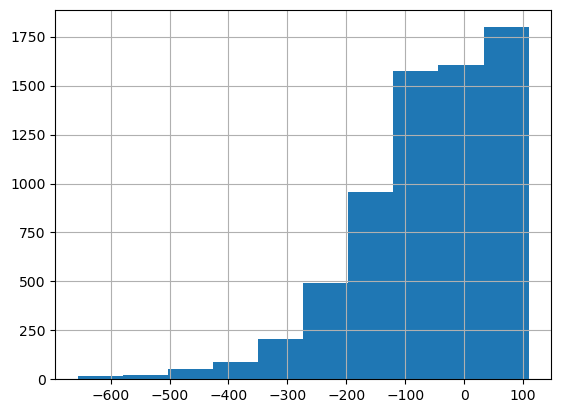

In [8]:
df['readability_score'].hist()

In [9]:
print("\n3. Step: Semantic Analysis (TF-IDF + LSA)")

# Creating the TF-IDF Matrix (Stop words: we eliminate unnecessary words in English)
tfidf = TfidfVectorizer(stop_words='english', max_features=4000)
tfidf_matrix = tfidf.fit_transform(df['lyrics'])


3. Step: Semantic Analysis (TF-IDF + LSA)


In [10]:
print(tfidf_matrix.shape)
print(tfidf_matrix)

(6813, 4000)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 401045 stored elements and shape (6813, 4000)>
  Coords	Values
  (0, 3777)	0.06813225479176108
  (0, 2860)	0.052025676375222034
  (0, 253)	0.09278451620723265
  (0, 2365)	0.12875105830504383
  (0, 2064)	0.05893612547845372
  (0, 3158)	0.0485754586890264
  (0, 2955)	0.051459522843899305
  (0, 3113)	0.062392646113821074
  (0, 3300)	0.27439079158409707
  (0, 3067)	0.06631510000835278
  (0, 391)	0.08143221410200184
  (0, 3003)	0.04860336029795501
  (0, 84)	0.26698636811057597
  (0, 2943)	0.08016771391656201
  (0, 1589)	0.048942838353931574
  (0, 3225)	0.04784347597962573
  (0, 2702)	0.07673334221815135
  (0, 2927)	0.06968760558760737
  (0, 961)	0.020862234604439107
  (0, 46)	0.05911996966944145
  (0, 392)	0.04727553202017202
  (0, 1450)	0.0335343746610753
  (0, 2354)	0.20513385267111633
  (0, 3936)	0.03486361939219393
  (0, 1478)	0.06279349866405805
  :	:
  (6812, 1344)	0.2503061316546291
  (6812, 2590)	0.2585541931

In [11]:
# Latent Semantic Analysis (LSA) - Dimension Reduction
n_components = 10
lsa = TruncatedSVD(n_components=n_components, random_state=42)
lsa_matrix = lsa.fit_transform(tfidf_matrix)

# Adding LSA results as columns to the main DataFrame
lsa_columns = [f'lsa_dim_{i+1}' for i in range(n_components)]
df_lsa = pd.DataFrame(lsa_matrix, columns=lsa_columns, index=df.index)
df = pd.concat([df, df_lsa], axis=1)

In [12]:
df.head()

,original_index,track_id,song_name,artist,genre,lyrics,chorus_ratio,syllable_density,sentiment_score,readability_score,lsa_dim_1,lsa_dim_2,lsa_dim_3,lsa_dim_4,lsa_dim_5,lsa_dim_6,lsa_dim_7,lsa_dim_8,lsa_dim_9,lsa_dim_10
0,17623,Pop_00001,A Child Is Born,Rihanna,Pop,As I was walkin' down the road to Bethlehem on...,0.7317,1.6751,0.9985,-213.015852,0.181620,-0.032062,0.074830,-0.052017,0.024681,0.013611,-0.108253,-0.050807,0.016758,-0.059504
1,17624,Pop_00002,A Girl Like Me,Rihanna,Pop,Some girls play the game \r\nThey all walk an...,0.6486,1.4463,0.9976,-288.069160,0.289125,-0.100884,-0.054164,0.023070,0.026756,0.028944,0.025261,-0.029579,0.242801,0.148430
2,17626,Pop_00003,American Oxygen,Rihanna,Pop,"[Chorus] \r\nBreathe out, breathe in \r\nAme...",0.8143,2.3005,0.9195,-215.421805,0.044864,-0.012872,0.002694,-0.021561,-0.003935,-0.000581,0.001150,-0.015095,0.007276,-0.002947
3,17627,Pop_00004,California King Bed,Rihanna,Pop,Chest to chest \r\nNose to nose \r\nPalm to ...,0.4894,1.6163,0.7930,-159.395000,0.101799,-0.005988,-0.027122,-0.045864,-0.010747,0.010495,-0.031751,-0.015326,-0.013313,0.020780
4,17628,Pop_00005,Cold Case Love,Rihanna,Pop,"On my roof (roof, roof, roof) \r\nDark and I'...",0.5424,1.4672,0.9987,-253.186955,0.209820,0.184694,-0.089020,0.051319,-0.092809,-0.019127,0.000481,-0.003425,0.001610,-0.025705


In [13]:
print("\n4. Step: Data Standardization")
features_to_scale = ['sentiment_score', 'readability_score'] + lsa_columns

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features_to_scale])

# Adding scaled data as new columns (prefixing them with 'scaled_')
scaled_columns = [f'scaled_{col}' for col in features_to_scale]
df_scaled = pd.DataFrame(scaled_features, columns=scaled_columns, index=df.index)
df = pd.concat([df, df_scaled], axis=1)


4. Step: Data Standardization


In [14]:
df.head()

,original_index,track_id,song_name,artist,genre,lyrics,chorus_ratio,syllable_density,sentiment_score,readability_score,lsa_dim_1,lsa_dim_2,lsa_dim_3,lsa_dim_4,lsa_dim_5,lsa_dim_6,lsa_dim_7,lsa_dim_8,lsa_dim_9,lsa_dim_10,scaled_sentiment_score,scaled_readability_score,scaled_lsa_dim_1,scaled_lsa_dim_2,scaled_lsa_dim_3,scaled_lsa_dim_4,scaled_lsa_dim_5,scaled_lsa_dim_6,scaled_lsa_dim_7,scaled_lsa_dim_8,scaled_lsa_dim_9,scaled_lsa_dim_10
0,17623,Pop_00001,A Child Is Born,Rihanna,Pop,As I was walkin' down the road to Bethlehem on...,0.7317,1.6751,0.9985,-213.015852,0.181620,-0.032062,0.074830,-0.052017,0.024681,0.013611,-0.108253,-0.050807,0.016758,-0.059504,0.730768,-1.258854,-0.181727,-0.218021,0.854540,-0.539246,0.391156,0.136847,-1.447807,-0.731282,0.235369,-0.870547
1,17624,Pop_00002,A Girl Like Me,Rihanna,Pop,Some girls play the game \r\nThey all walk an...,0.6486,1.4463,0.9976,-288.069160,0.289125,-0.100884,-0.054164,0.023070,0.026756,0.028944,0.025261,-0.029579,0.242801,0.148430,0.729667,-1.878819,1.046809,-0.902699,-0.574128,0.390248,0.418081,0.346083,0.440494,-0.415330,3.680571,2.338876
2,17626,Pop_00003,American Oxygen,Rihanna,Pop,"[Chorus] \r\nBreathe out, breathe in \r\nAme...",0.8143,2.3005,0.9195,-215.421805,0.044864,-0.012872,0.002694,-0.021561,-0.003935,-0.000581,0.001150,-0.015095,0.007276,-0.002947,0.634108,-1.278728,-1.744547,-0.027111,0.055600,-0.162233,0.019750,-0.056819,0.099490,-0.199752,0.090860,0.002400
3,17627,Pop_00004,California King Bed,Rihanna,Pop,Chest to chest \r\nNose to nose \r\nPalm to ...,0.4894,1.6163,0.7930,-159.395000,0.101799,-0.005988,-0.027122,-0.045864,-0.010747,0.010495,-0.031751,-0.015326,-0.013313,0.020780,0.479330,-0.815929,-1.093905,0.041380,-0.274630,-0.463068,-0.068659,0.094325,-0.365821,-0.203193,-0.222948,0.368619
4,17628,Pop_00005,Cold Case Love,Rihanna,Pop,"On my roof (roof, roof, roof) \r\nDark and I'...",0.5424,1.4672,0.9987,-253.186955,0.209820,0.184694,-0.089020,0.051319,-0.092809,-0.019127,0.000481,-0.003425,0.001610,-0.025705,0.731013,-1.590681,0.140534,1.938396,-0.960181,0.739948,-1.133738,-0.309909,0.090036,-0.026062,0.004501,-0.348863


In [15]:
df.to_csv("billboard_lyrics_features_vectorized.csv")